In [ ]:
# Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
# Load the Dataset
df = pd.read_csv("C:/Users/temp.admin/Documents/Stats AIDS/diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nTarget Variable Distribution:")
print(df["Outcome"].value_counts())

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [5]:
# Separate input features and target variable 
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [6]:
# Handle Missing or invalid values  
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = X[invalid_columns].replace(0, np.nan)

print("Missing Values in Each Column:")
print(X.isnull().sum())

Missing Values in Each Column:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [7]:
# Split the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (614, 8)
Testing Data: (154, 8)


In [8]:
# Build the classification models
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Logistic Regression
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# K-Nearest Neighbors
knn_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Decision Tree
tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=42))
])

print("Three classification models created successfully.")

Three classification models created successfully.


In [9]:
# Train the models 
logistic_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [10]:
#generate predictions 
y_pred_lr = logistic_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

print("Logistic Regression Predictions:")
print(y_pred_lr[:10])

print("\nKNN Predictions:")
print(y_pred_knn[:10])

print("\nDecision Tree Predictions:")
print(y_pred_tree[:10])

Logistic Regression Predictions:
[1 0 0 0 0 0 0 1 0 1]

KNN Predictions:
[1 0 0 1 0 0 0 1 0 1]

Decision Tree Predictions:
[1 0 0 1 1 0 0 1 0 1]



 Logistic Regression
[[82 18]
 [27 27]]


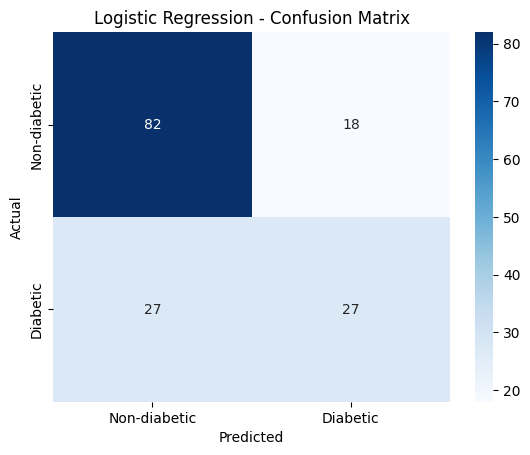


 KNN
[[83 17]
 [21 33]]


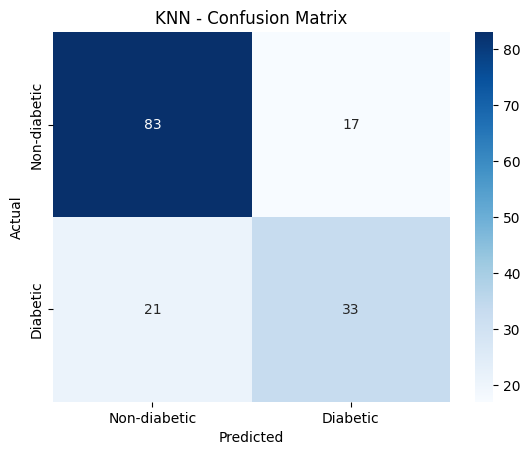


 Decision Tree
[[79 21]
 [28 26]]


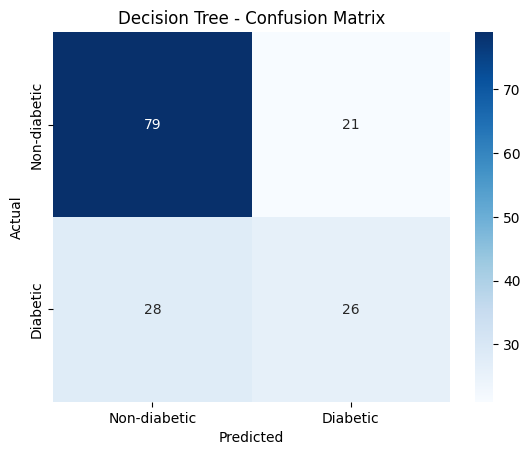

In [12]:
# Construct the confusion metrix
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree
}

for name, predictions in models_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    print("\n", name)
    print(cm)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-diabetic", "Diabetic"],
        yticklabels=["Non-diabetic", "Diabetic"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name + " - Confusion Matrix")
    plt.show()

In [13]:
# Calculate classification performance metrices
results = []

for name, predictions in models_predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7078     0.6000  0.5000    0.5455
1                  KNN    0.7532     0.6600  0.6111    0.6346
2        Decision Tree    0.6818     0.5532  0.4815    0.5149


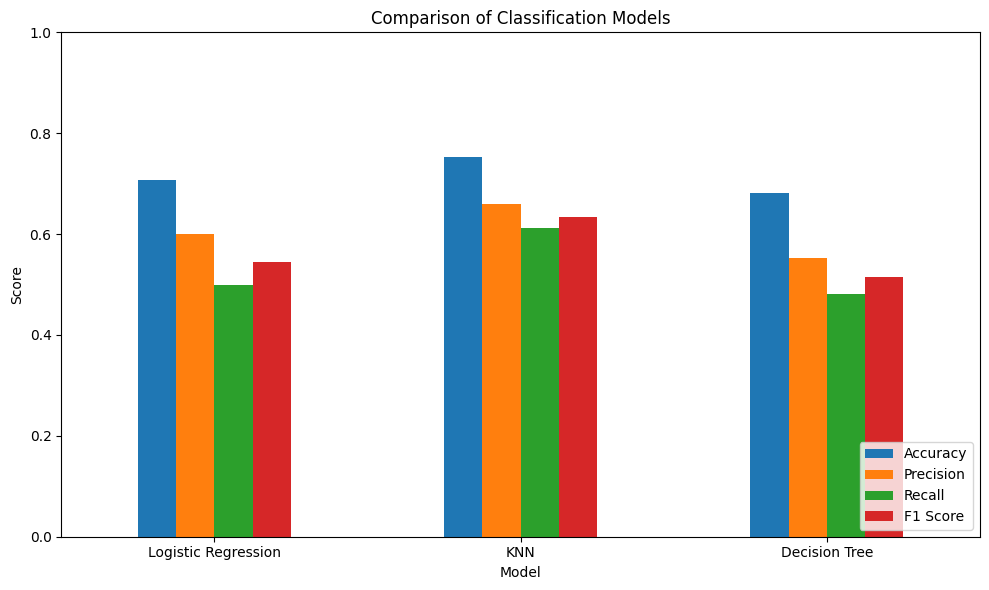

In [14]:
# Compare and interpret the results 
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar", figsize=(10, 6))

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()